<a href="https://colab.research.google.com/github/dhrutiv1129/mri-shortcut-audit/blob/main/brain_mri_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain MRI Preprocessing

Minimal preprocessing pipeline for the Sartaj Brain Tumor Classification (MRI) dataset stored in the shared Google Drive folder.

**Pipeline (applied to every image):**
1. Load as RGB, grayscale MRI replicated across three channels for ResNet-18 compatibility
2. Resize to 224 by 224 (bilinear) to match ResNet-18 pretrained input resolution
3. Convert to tensor: rescales pixel values from [0, 255] integers to [0, 1] floats
4. Normalize with ImageNet per-channel mean and standard deviation

**Outputs:** `train_loader`, `val_loader`, `test_loader`, `classes`, ready for ResNet-18 training.

## 1. Mount Google Drive

The dataset lives in the shared "Deep Learning Final Project" folder. If the folder is under **Shared with me** rather than **My Drive**, first add a shortcut: right-click the folder in Drive, choose Organize, then Add shortcut, and place it in My Drive. Otherwise the path below will not resolve.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports and transform

Defines the four-step preprocessing pipeline as a single `torchvision.transforms.Compose`.

In [ ]:
import torch
from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),       # step 2: bilinear resize to 224x224
    transforms.ToTensor(),               # step 3: PIL -> tensor, rescales [0,255] -> [0,1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # step 4: ImageNet normalization
])

def rgb_loader(path):
    # step 1: load as 3-channel RGB (grayscale replicated across channels)
    return Image.open(path).convert('RGB')

## 3. Load and merge Sartaj Training and Testing

Sartaj ships with separate `Training/` and `Testing/` folders. The original test split is small and has known labeling issues, so they are merged here and resplit in the next cell.

In [ ]:
import os

DATA_ROOT = DATA_ROOT = '/content/drive/MyDrive/Deep Learning Final Project/BrainMRISartaj'
print(os.listdir('/content/drive/MyDrive/Deep Learning Final Project'))

training = datasets.ImageFolder(f'{DATA_ROOT}/Training', loader=rgb_loader, transform=transform)
testing = datasets.ImageFolder(f'{DATA_ROOT}/Testing', loader=rgb_loader, transform=transform)

assert training.classes == testing.classes, 'Class mismatch between Training and Testing folders'
classes = training.classes
full = ConcatDataset([training, testing])

print(f'Classes: {classes}')
print(f'Training folder: {len(training)} images')
print(f'Testing folder: {len(testing)} images')
print(f'Merged total:    {len(full)} images')

['DL Proposal.gdoc', 'BrainMRISartaj', 'BrainMRINavoneel', 'brain_mri_preprocessing (1).ipynb', 'DL Project Ideas.gdoc', 'baseline_resnet18.pth', 'brain_mri_preprocessing.ipynb']
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Training folder: 2870 images
Testing folder: 394 images
Merged total:    3264 images


## 4. Train, validation, test split

Partitions the merged dataset 70/15/15 with a fixed seed for reproducibility across team members.

In [ ]:
n = len(full)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

g = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(full, [n_train, n_val, n_test], generator=g)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 2284 | Val: 489 | Test: 491


## 5. DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## 6. Sanity check

Pulls one batch and displays 16 images with their class labels. Confirms shapes, normalization, and class assignments look right.

Batch image tensor shape: (32, 3, 224, 224)
Pixel range after normalization: [-2.118, 2.640]


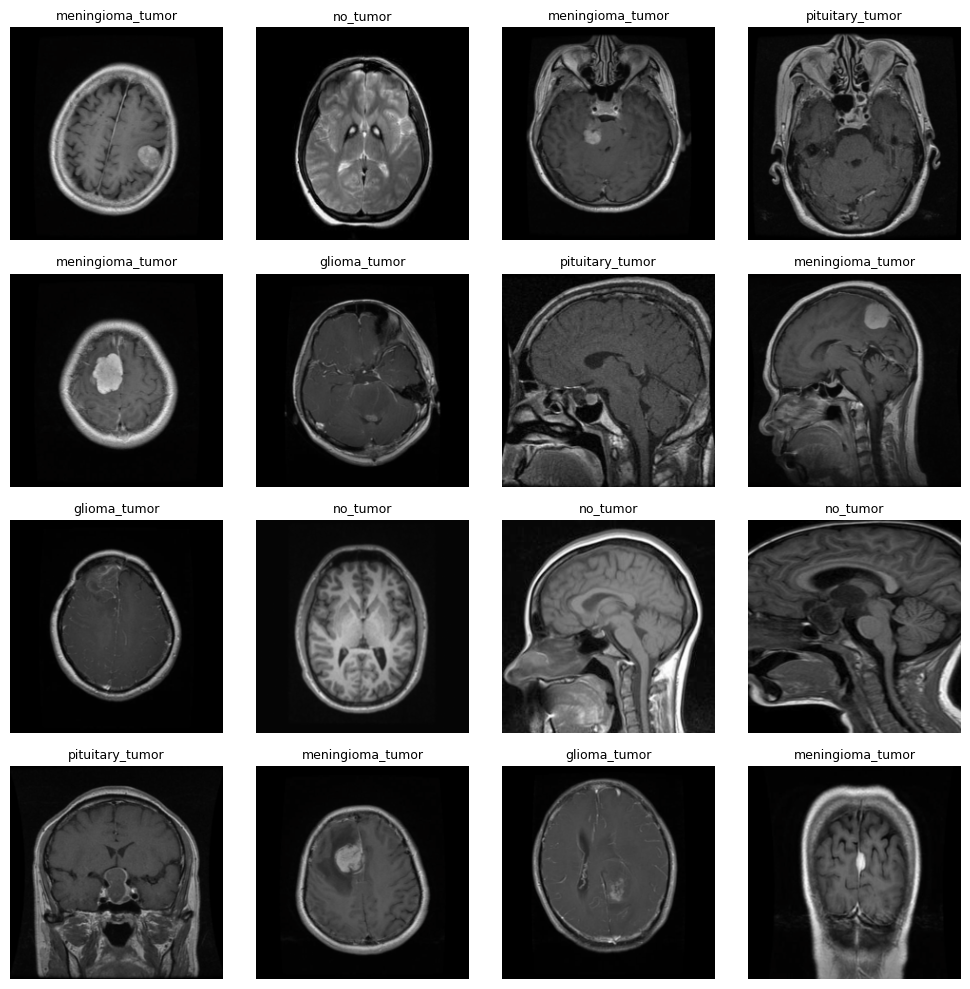

In [ ]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
print(f'Batch image tensor shape: {tuple(images.shape)}')
print(f'Pixel range after normalization: [{images.min():.3f}, {images.max():.3f}]')

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]).permute(1, 2, 0).numpy())
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
import torchvision.models as models

# 1. MODEL
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)  # 4 classes for Sartaj dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 2. LOSS & OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 3. TRAINING LOOP
for epoch in range(10):
    model.train()
    running_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(train_ds)

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_ds)

    print(f"Epoch {epoch+1}: loss={running_loss:.3f}, train_acc={acc:.3f}, val_acc={val_acc:.3f}")

# 4. SAVE CHECKPOINT
torch.save(model.state_dict(), '/content/drive/MyDrive/Deep Learning Final Project/baseline_resnet18.pth')
print("Model saved.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Epoch 1: loss=33.712, train_acc=0.816, val_acc=0.941
Epoch 2: loss=6.728, train_acc=0.972, val_acc=0.953
Epoch 3: loss=2.118, train_acc=0.996, val_acc=0.941
Epoch 4: loss=1.056, train_acc=0.998, val_acc=0.963
Epoch 5: loss=0.856, train_acc=0.997, val_acc=0.959
Epoch 6: loss=0.513, train_acc=0.999, val_acc=0.961
Epoch 7: loss=0.397, train_acc=0.999, val_acc=0.955
Epoch 8: loss=1.140, train_acc=0.994, val_acc=0.924
Epoch 9: loss=6.198, train_acc=0.971, val_acc=0.924
Epoch 10: loss=2.935, train_acc=0.988, val_acc=0.949
Model saved.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.3f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Recall:    {recall_score(all_labels, all_preds, average='macro'):.3f}")

Accuracy:  0.953
Precision: 0.953
Recall:    0.956
